In [91]:
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd

In [92]:
from sklearn.datasets import make_classification

X,y=make_classification(n_samples=1000, n_features=2, n_redundant=0, n_clusters_per_class=2, random_state=42)

In [93]:
X

array([[-0.99910178, -0.66386   ],
       [ 1.24668618,  1.15359685],
       [ 0.96277683,  0.85939747],
       ...,
       [-0.10126746, -1.59017563],
       [ 0.64376105, -0.78053855],
       [ 0.69852984, -1.27940455]])

<Axes: >

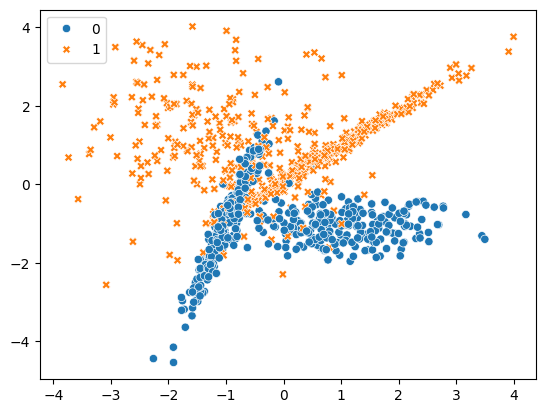

In [94]:
sns.scatterplot(x=X[:,0],y=X[:,1],hue=y,style=y)

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [96]:
from sklearn.svm import SVC
model= SVC(kernel='linear',C=1)
model.fit(X_train,y_train)

SVC(C=1, kernel='linear')

In [ ]:
pred=model.predict(X_test)

In [98]:
from sklearn import metrics
print("Accuracy:", metrics.classification_report(y_test, pred))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, pred))

Accuracy:               precision    recall  f1-score   support

           0       0.86      0.88      0.87       121
           1       0.89      0.86      0.87       129

    accuracy                           0.87       250
   macro avg       0.87      0.87      0.87       250
weighted avg       0.87      0.87      0.87       250

Confusion Matrix:
 [[107  14]
 [ 18 111]]


# Find best param using girdsearchCV

In [100]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10], 
            'kernel': ['linear', 'rbf'],
            'gamma': [0.01, 0.1, 1], 
            'degree': [2, 3, 4]
            }

grid= GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', verbose=2)
grid.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END .........C=0.1, degree=2, gamma=0.01, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ..........C=0.1, degree=2, gamma=0.1, kernel=linear; total time=   0.0s
[CV] END ..........C=0.1, degree=2, gamma=0.1, 

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.1, 1, 10], 'degree': [2, 3, 4],
                         'gamma': [0.01, 0.1, 1], 'kernel': ['linear', 'rbf']},
             scoring='accuracy', verbose=2)

In [101]:
grid.best_params_

{'C': 10, 'degree': 2, 'gamma': 1, 'kernel': 'rbf'}

In [ ]:
pred1=grid.predict(X_test)
print("Accuracy:", metrics.classification_report(y_test, pred1))
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, pred1))

Accuracy:               precision    recall  f1-score   support

           0       0.86      0.98      0.91       121
           1       0.97      0.84      0.90       129

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.92      0.91      0.91       250

Confusion Matrix:
 [[118   3]
 [ 20 109]]
